# External validation on mcPHASES (hormonal ground truth)

The HSMM in `cycle_hsmm_model.ipynb` and the change-point in `cycle_transition_model.ipynb`
were only ever checked against **Garmin's own calendar rule** — agreement between two
algorithms, not against truth. The [mcPHASES](https://physionet.org/content/mcphases/)
dataset fixes that: 42 participants with Fitbit biometrics **and** Mira hormone assays
(LH, estrogen/E3G, PdG) over ~90-day intervals, so we can score the model's follicular→luteal
boundary against the **LH surge** — the physiological ovulation marker.

**Signal mapping (Fitbit → our Garmin schema).** `resting_hr ← resting_heart_rate`,
`hrv_rmssd ← nightly mean of HRV rmssd`, `avg_sleep_respiration ← full-sleep breathing rate`.
Garmin's `avg_sleep_stress` has **no clean Fitbit equivalent**, so the model runs on the
remaining **three** signals here.

**Truth.** Per cycle, ovulation = **LH-peak day** (gated by a surge test), extracted by
`analysis/mcphases_truth.py`. Because the biometric luteal onset physiologically *lags* true
ovulation by the progesterone/RHR delay, we expect the model boundary `b` to land a couple of
days **after** the LH peak — so we report both the raw offset and a bias-corrected precision.

**Emissions.** Signals are robust-standardized **per person** (median/MAD), which removes
cross-person scale, so emission parameters can be **pooled across participants** (the shared
follicular↔luteal *shape*). This is the design intended for the future multi-person Garmin
collector. We show pooled (primary) and per-person side by side.


In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "analysis").exists():
    REPO_ROOT = Path("/home/elsa/projects/garmin")
sys.path.insert(0, str(REPO_ROOT / "analysis"))
import importlib
import mcphases_truth as mcphases_truth_module
importlib.reload(mcphases_truth_module)
from mcphases_truth import (build_daily_table, add_cycle_structure,
                            extract_ovulation_truth, SIGNALS)

MCPHASES_DIR = REPO_ROOT / "data/external/physionet.org/files/mcphases/1.0.0"
CACHE = REPO_ROOT / "data/external/mcphases_daily.csv"

daily = build_daily_table(MCPHASES_DIR, cache_path=CACHE)   # cached for re-runs
df = add_cycle_structure(daily)
truth = extract_ovulation_truth(df)

SIG = SIGNALS                 # resting_hr, hrv_rmssd, avg_sleep_respiration
D = len(SIG)
comp = truth[truth["cycle_len"].notna()]
conf = comp[comp["confident"]]
print(f"participants: {df['id'].nunique()} | complete cycles: {len(comp)} | "
      f"confident LH surge: {len(conf)} ({len(conf)/len(comp)*100:.0f}%)")
print("signal coverage:", {s: f"{daily[s].notna().mean()*100:.0f}%" for s in SIG})
print("zero-sentinel counts:", {s: int((daily[s] <= 0).sum()) for s in SIG})


## Ground truth — and a first independent check

Two facts fall out of the hormonal truth before any model runs:

- **Hormonal luteal length ≈ 13–14 days** (median 14, mean 13.3, std 3.3). This *independently*
  confirms the `DUR_MU = 13` luteal-duration prior and the HSMM's median-13 output — Garmin's
  calendar rule and real hormones now agree, so the prior is not circular.
- **The study's own `Luteal` label starts ~3 days after the LH peak** — the biometric lag we
  expect the model boundary to inherit.


In [ ]:
print("Hormonal luteal length (cycle_len - LH-peak day):")
print(f"   median {conf['luteal_len'].median():.0f}  mean {conf['luteal_len'].mean():.1f}  "
      f"std {conf['luteal_len'].std():.1f}")
print(f"True ovulation (LH-peak) cycle_day: median {conf['ov_day'].median():.0f}  "
      f"IQR {conf['ov_day'].quantile(.25):.0f}-{conf['ov_day'].quantile(.75):.0f}")
print(f"phase Luteal-onset  -  LH-peak day: median {(conf['luteal_onset']-conf['ov_day']).median():.1f} d (biometric lag)")
conf.head(8)


## The model — same HSMM, transferred verbatim

Exactly the `cycle_hsmm_model.ipynb` recipe: per-person robust standardization; follicular
emission seeded from the **post-menstrual window** `[period_end, period_end+6)`; luteal emission
from the last 6 pre-menstrual days; per-cycle MAP boundary with the soft luteal-duration prior.
The only differences are three signals instead of four (no sleep-stress) and that emissions can
be **pooled** across participants.


In [ ]:
MIN_AFTER, MIN_LUT, MAX_LUT = 4, 4, 19
DUR_MU, DUR_SD = 13.0, 2.5
ZCOLS = [f"z_{s}" for s in SIG]


def standardize_per_person(df):
    df = df.copy()
    for s in SIG:
        df[f"z_{s}"] = np.nan
    for (pid, iv), _ in df.groupby(["id", "study_interval"], sort=False):
        m = (df["id"] == pid) & (df["study_interval"] == iv)
        block = df.loc[m, SIG].interpolate(limit_direction="both")
        med = block.median()
        mad = ((block - med).abs().median() * 1.4826).replace(0, 1.0)
        for s in SIG:
            df.loc[m, f"z_{s}"] = (block[s] - med[s]) / mad[s]
    return df


def cycle_iter(df):
    for keys, gc in df.groupby(["id", "study_interval", "cycle_id"], sort=False):
        if pd.isna(gc["cycle_len"].iloc[0]):
            continue
        yield keys, gc.sort_values("cycle_day")


def anchor_rows(df):
    F, L = [], []
    for _, gc in cycle_iter(df):
        cl = int(gc["cycle_len"].iloc[0]); pe = int(gc["period_end"].iloc[0])
        cd = gc["cycle_day"].to_numpy(); ip = gc["is_period"].to_numpy()
        Z = gc[ZCOLS].to_numpy()
        hi = min(pe + 6, cl - 16)
        F.append(Z[(~ip) & (cd >= pe) & (cd < hi)])
        L.append(Z[(~ip) & (cd >= cl - 6) & (cd < cl)])
    stack = lambda a: np.vstack(a) if a else np.empty((0, D))
    return stack(F), stack(L)


def fit(sub):
    """Gaussian emissions from anchor days; None if too few clean rows."""
    F, L = anchor_rows(sub)
    F = F[~np.isnan(F).any(1)]; L = L[~np.isnan(L).any(1)]
    if len(F) < D + 2 or len(L) < D + 2:
        return None
    return (F.mean(0), np.cov(F.T) + 0.2 * np.eye(D),
            L.mean(0), np.cov(L.T) + 0.2 * np.eye(D))


def logmvn(Xm, mu, Sig):
    Lc = np.linalg.cholesky(Sig)
    ld = 2 * np.sum(np.log(np.diag(Lc)))
    sol = np.linalg.solve(Lc, (Xm - mu).T)
    return -0.5 * (D * np.log(2 * np.pi) + ld + np.sum(sol ** 2, 0))


def segment(gc, em, use_dur=True):
    muF, SigF, muL, SigL = em
    cl = int(gc["cycle_len"].iloc[0]); pe = int(gc["period_end"].iloc[0])
    cd = gc["cycle_day"].to_numpy(); ip = gc["is_period"].to_numpy()
    Xc = gc[ZCOLS].to_numpy()
    if np.isnan(Xc).any():
        return None
    lF = logmvn(Xc, muF, SigF); lL = logmvn(Xc, muL, SigL)
    c0 = max(pe + MIN_AFTER, cl - MAX_LUT); c1 = cl - MIN_LUT
    if c1 < c0:
        return None
    cands = np.arange(c0, c1 + 1); sc = np.empty(len(cands))
    for i, b in enumerate(cands):
        s = lF[(~ip) & (cd >= pe) & (cd < b)].sum() + lL[(~ip) & (cd >= b)].sum()
        if use_dur:
            s += -0.5 * ((cl - b - DUR_MU) / DUR_SD) ** 2
        sc[i] = s
    return int(cands[np.argmax(sc)])


def run(dfz, emission="pooled", use_dur=True):
    pooled = fit(dfz) if emission == "pooled" else None
    rows = []
    for (pid, iv), gb in dfz.groupby(["id", "study_interval"], sort=False):
        em = pooled if emission == "pooled" else fit(gb)
        if em is None:
            continue
        for keys, gc in cycle_iter(gb):
            b = segment(gc, em, use_dur)
            if b is not None:
                rows.append({"id": pid, "study_interval": iv, "cycle_id": keys[2],
                             "cycle_len": int(gc["cycle_len"].iloc[0]), "b": b})
    res = pd.DataFrame(rows).merge(
        truth[["id", "study_interval", "cycle_id", "ov_day", "luteal_onset", "confident"]],
        on=["id", "study_interval", "cycle_id"], how="left")
    return res[res["confident"] == True]        # noqa: E712


dfz = standardize_per_person(df)
POOLED_EM = fit(dfz)
print("Pooled emission means (per-person-standardized units):")
print("  follicular:", dict(zip(SIG, POOLED_EM[0].round(2))))
print("  luteal    :", dict(zip(SIG, POOLED_EM[2].round(2))))


In [28]:
def metrics(res, truth_col):
    d = (res["b"] - res[truth_col]).dropna()
    dc = d - d.median()
    return {"n": len(d), "bias": round(d.median(), 1),
            "MAD": round(dc.abs().median(), 1),
            "within2d": round((d.abs() <= 2).mean() * 100),
            "within3d": round((d.abs() <= 3).mean() * 100),
            "within2d_bc": round((dc.abs() <= 2).mean() * 100),
            "within3d_bc": round((dc.abs() <= 3).mean() * 100)}

res_person = run(dfz, "per-person")
res_pooled = run(dfz, "pooled")

print("Boundary b  vs  TRUE ovulation (LH peak)   [bias = biometric lag; _bc = bias-corrected]")
for name, r in [("per-person emissions", res_person), ("pooled emissions", res_pooled)]:
    print(f"  {name:22s}", metrics(r, "ov_day"))
print("\nBoundary b  vs  phase LUTEAL-ONSET label")
for name, r in [("per-person emissions", res_person), ("pooled emissions", res_pooled)]:
    print(f"  {name:22s}", metrics(r, "luteal_onset"))
print("\nFor reference, vs Garmin's calendar rule on the owner's single record: within-2d ~65%.")


Boundary b  vs  TRUE ovulation (LH peak)   [bias = biometric lag; _bc = bias-corrected]
  per-person emissions   {'n': 86, 'bias': np.float64(2.0), 'MAD': np.float64(3.0), 'within2d': 40, 'within3d': 51, 'within2d_bc': 42, 'within3d_bc': 55}
  pooled emissions       {'n': 90, 'bias': np.float64(3.5), 'MAD': np.float64(1.5), 'within2d': 31, 'within3d': 42, 'within2d_bc': 51, 'within3d_bc': 72}

Boundary b  vs  phase LUTEAL-ONSET label
  per-person emissions   {'n': 84, 'bias': np.float64(-2.0), 'MAD': np.float64(3.0), 'within2d': 42, 'within3d': 55, 'within2d_bc': 42, 'within3d_bc': 54}
  pooled emissions       {'n': 88, 'bias': np.float64(0.0), 'MAD': np.float64(2.0), 'within2d': 65, 'within3d': 80, 'within2d_bc': 65, 'within3d_bc': 80}

For reference, vs Garmin's calendar rule on the owner's single record: within-2d ~65%.


## Diagnostics

The HSMM boundary `b` is interpreted as the **wearable biometric luteal transition**, so the
primary validation target is the study's labelled **luteal onset**. The LH peak is shown
separately because it is the hormonal ovulation marker that usually occurs a few days earlier.

Left: raw offset from LH peak, showing the physiological lag. Middle: raw offset from labelled
luteal onset, showing whether the boundary matches the transition label. Right: pooled emission
means, a physiological direction check.


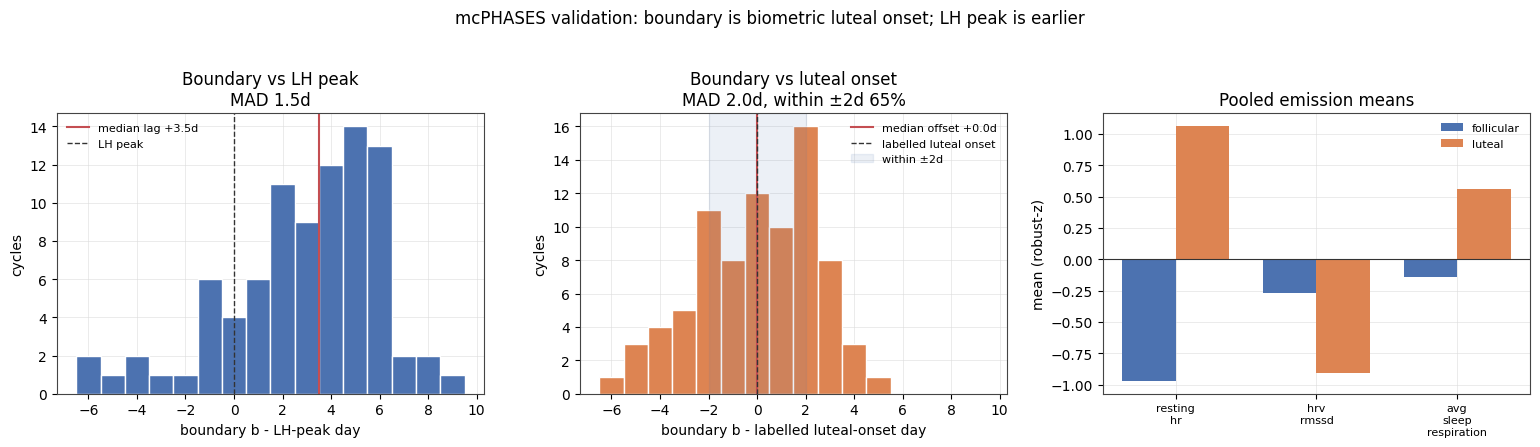

In [30]:
plt.style.use("default")
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.3))
fig.set_facecolor("white")

for ax in axes:
    ax.set_facecolor("white")
    ax.tick_params(axis="both", colors="black", labelcolor="black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.title.set_color("black")
    for spine in ax.spines.values():
        spine.set_color("#444444")
    ax.grid(True, color="#dddddd", linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)

# 1) Boundary vs hormonal LH peak: this shows the lag from true ovulation marker.
d_lh = (res_pooled["b"] - res_pooled["ov_day"]).dropna()
axes[0].hist(d_lh, bins=np.arange(-6.5, 9.6, 1), color="#4c72b0", edgecolor="white")
axes[0].axvline(d_lh.median(), color="#c44e52", lw=1.5,
                label=f"median lag {d_lh.median():+.1f}d")
axes[0].axvline(0, color="#333333", ls="--", lw=1, label="LH peak")
axes[0].set_xlabel("boundary b - LH-peak day")
axes[0].set_ylabel("cycles")
axes[0].set_title(f"Boundary vs LH peak\nMAD {(d_lh - d_lh.median()).abs().median():.1f}d")
axes[0].legend(frameon=False, fontsize=8)

# 2) Boundary vs labelled luteal onset: this is the direct transition comparison.
d_lut = (res_pooled["b"] - res_pooled["luteal_onset"]).dropna()
axes[1].hist(d_lut, bins=np.arange(-6.5, 9.6, 1), color="#dd8452", edgecolor="white")
axes[1].axvline(d_lut.median(), color="#c44e52", lw=1.5,
                label=f"median offset {d_lut.median():+.1f}d")
axes[1].axvline(0, color="#333333", ls="--", lw=1, label="labelled luteal onset")
axes[1].axvspan(-2, 2, color="#4c72b0", alpha=0.10, label="within ±2d")
axes[1].set_xlabel("boundary b - labelled luteal-onset day")
axes[1].set_ylabel("cycles")
axes[1].set_title(f"Boundary vs luteal onset\nMAD {(d_lut - d_lut.median()).abs().median():.1f}d, within ±2d {(d_lut.abs() <= 2).mean() * 100:.0f}%")
axes[1].legend(frameon=False, fontsize=8)

# 3) Emission direction check.
muF, _, muL, _ = POOLED_EM
x = np.arange(len(SIG))
w = 0.38
axes[2].bar(x - w / 2, muF, w, label="follicular", color="#4c72b0")
axes[2].bar(x + w / 2, muL, w, label="luteal", color="#dd8452")
axes[2].axhline(0, color="#333333", lw=0.8)
axes[2].set_xticks(x)
axes[2].set_xticklabels([s.replace("_", "\n") for s in SIG], fontsize=8, color="black")
axes[2].set_ylabel("mean (robust-z)")
axes[2].set_title("Pooled emission means")
axes[2].legend(frameon=False, fontsize=8)

fig.suptitle("mcPHASES validation: boundary is biometric luteal onset; LH peak is earlier", y=1.03, color="black")
fig.tight_layout()
plt.show()


## Findings

Against hormonal ground truth across **~90 confident cycles from 29 participants**:

- **The HSMM boundary is a biometric luteal-onset estimate, not exact LH ovulation.** Against the
  LH peak, pooled emissions have a median bias of **+3.5 days**: the model boundary usually lands
  several days after the hormone surge. That direction is physiologically plausible because RHR,
  HRV, and respiration shift after the ovulatory hormone event, not necessarily on the LH-peak day.
- **Pooling improves consistency but introduces a fixed lag.** Per-person emissions have smaller
  LH-peak bias (**+2 days**) but noisier timing (**MAD 3 days**). Pooled emissions have larger
  bias (**+3.5 days**) but tighter spread (**MAD 1.5 days**). After removing the fixed bias,
  pooled emissions place **51%** of cycles within ±2 days and **72%** within ±3 days of the LH peak.
- **The boundary aligns better with the study's luteal-onset label.** Against labelled luteal
  onset, pooled emissions have **0-day median bias**, **MAD 2 days**, **65% within ±2 days**, and
  **80% within ±3 days**. This supports the interpretation that the HSMM is detecting the wearable
  physiological luteal shift rather than the LH surge itself.
- **The emission directions now look physiologically correct after removing zero sentinels.**
  Pooled luteal means are higher for `resting_hr` and `avg_sleep_respiration`, and lower for
  `hrv_rmssd`, compared with follicular. The earlier apparent Fitbit RHR inversion was caused by
  stale cached daily data that still contained zero sentinel values.

## Next-step levers (documented, not yet pursued)

1. **Report two targets separately** — exact LH peak and biometric luteal onset are related but not
   identical. The model should not be described as exact ovulation unless a lag correction is
   explicitly applied.
2. **Temperature done right** — use baseline-relative/biphasic temperature features, not raw
   temperature as another Gaussian dimension.
3. **Hierarchical / partially-pooled emissions** — shrink each person toward the population mean
   instead of all-or-nothing pooling.
4. **Discriminative emissions** — swap the Gaussian for a calibrated `P(luteal | features)` inside
   the same HSMM.
